In [1]:
# main_report.ipynb
# Reproduces every figure and number reported for Project 6.
# No training happens here: all models are loaded from saved weights.
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print('device:', device)

z_dim = 7
num_classes = 10

device: cuda:0


In [2]:
d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)
for k, v in d.items():
    print(k, tuple(v.shape), v.dtype)

# the 120 real test images used as a reference point in the metrics below
real_imgs   = d['test_images'][:120].float()
real_labels = d['test_labels'][:120]

train_images (60000, 1, 20, 20) torch.float32
train_labels (60000,) torch.int64
test_images (10000, 1, 20, 20) torch.float32
test_labels (10000,) torch.int64


In [3]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 5: 64x3x3 -> 256x1x1  (kernel 3 instead of 4, the feature map
            # is 3x3 here rather than 4x4 because the input is 20x20 not 28x28)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu,logvar = torch.chunk(x, 2, dim=1)
        return mu,logvar

In [4]:
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3  (mirrors the encoder's 3x3 feature map)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 3: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 4: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 5: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat  = self.decoder_backbone(z)
        # z shape: (batch_size, z_dim)
        return x_hat

In [5]:
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

In [6]:
cvae_base = cVAE(z_dim, num_classes).to(device)
cvae_base.load_state_dict(torch.load('cvae_baseline.pth', map_location=device))
cvae_base.eval()

cvae_disc = cVAE(z_dim, num_classes).to(device)
cvae_disc.load_state_dict(torch.load('cvae_disc.pth', map_location=device))
cvae_disc.eval()

print('baseline params:', sum(p.numel() for p in cvae_base.parameters()))
print('disc     params:', sum(p.numel() for p in cvae_disc.parameters()))

baseline params: 350107
disc     params: 350107


baseline final: train 2.3520  test 2.0541
disc     final: train 3.3537  test 2.2658  D 0.6677  adv 0.7562


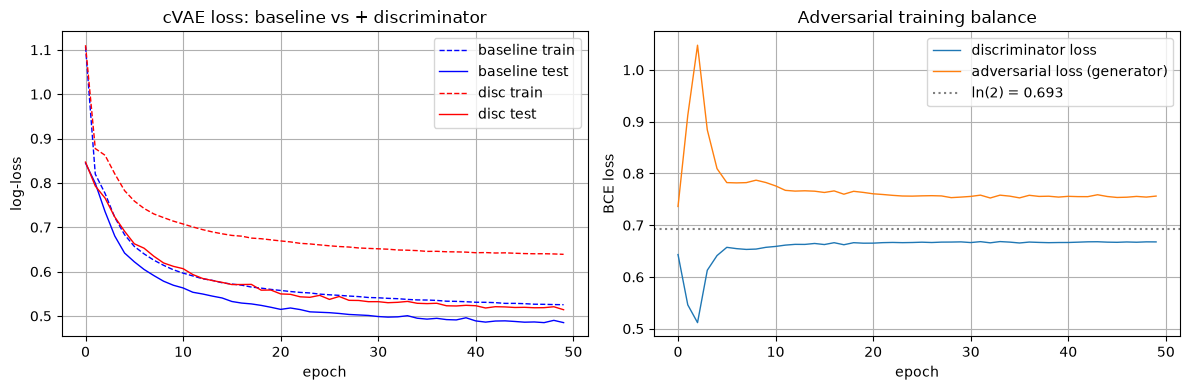

In [7]:
# results_baseline.pkl: (50, 2) = [train loss, test loss]
# results_disc.pkl:     (50, 4) = [train loss, test loss, discriminator loss, adversarial loss]
with open('results_baseline.pkl', 'rb') as f:
    losses_base = np.array(pickle.load(f)['losses'])
with open('results_disc.pkl', 'rb') as f:
    losses_disc = np.array(pickle.load(f)['losses'])

print('baseline final: train %.4f  test %.4f' % (losses_base[-1, 0], losses_base[-1, 1]))
print('disc     final: train %.4f  test %.4f  D %.4f  adv %.4f'
      % tuple(losses_disc[-1]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: total loss, log10(1+loss) as in the tutorial plots
axes[0].plot(np.log10(1 + losses_base[:, 0]), 'b--', label='baseline train', linewidth=1)
axes[0].plot(np.log10(1 + losses_base[:, 1]), 'b',   label='baseline test',  linewidth=1)
axes[0].plot(np.log10(1 + losses_disc[:, 0]), 'r--', label='disc train',     linewidth=1)
axes[0].plot(np.log10(1 + losses_disc[:, 1]), 'r',   label='disc test',      linewidth=1)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('log-loss')
axes[0].set_title('cVAE loss: baseline vs + discriminator')
axes[0].legend(); axes[0].grid()

# right: the two adversarial terms, only defined for the modified model.
# D loss near ln(2) = 0.693 means the discriminator cannot tell real from
# reconstructed, i.e. the adversarial game stayed balanced.
axes[1].plot(losses_disc[:, 2], label='discriminator loss', linewidth=1)
axes[1].plot(losses_disc[:, 3], label='adversarial loss (generator)', linewidth=1)
axes[1].axhline(np.log(2), color='grey', linestyle=':', label='ln(2) = 0.693')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('BCE loss')
axes[1].set_title('Adversarial training balance')
axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.savefig('curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
def sample_grid(model, z, title, savepath, num_samples=12, num_classes=10):
    """
    Conditional sampling: decode the SAME latent vectors z once per digit class.
    z is read back from the pickle saved during training, so the grid is
    identical to the one in the report on any machine (re-seeding the RNG is
    not guaranteed to give the same numbers across devices).
    returns: (num_classes, num_samples, 1, 20, 20)
    """
    model.eval()
    z = z.to(device)
    with torch.no_grad():
        all_conditions = torch.eye(num_classes).to(device)
        all_xhat = []
        for cond in all_conditions:
            x_hat = model.decode(z, cond.repeat(z.shape[0], 1)).cpu()
            all_xhat.append(x_hat)
        all_xhat = torch.stack(all_xhat)

    fig, axes = plt.subplots(num_samples, num_classes, figsize=(12, 14))
    for c in range(num_classes):
        for i in range(num_samples):
            axes[i, c].imshow(all_xhat[c, i].squeeze(), cmap='gray')
            if i == 0:
                axes[i, c].set_title(f'Class {c}')
            axes[i, c].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return all_xhat


with open('samples_baseline.pkl', 'rb') as f:
    z_base = pickle.load(f)['z']
with open('samples_disc.pkl', 'rb') as f:
    z_disc = pickle.load(f)['z']
print('z shapes:', tuple(z_base.shape), tuple(z_disc.shape))

z shapes: (12, 7) (12, 7)


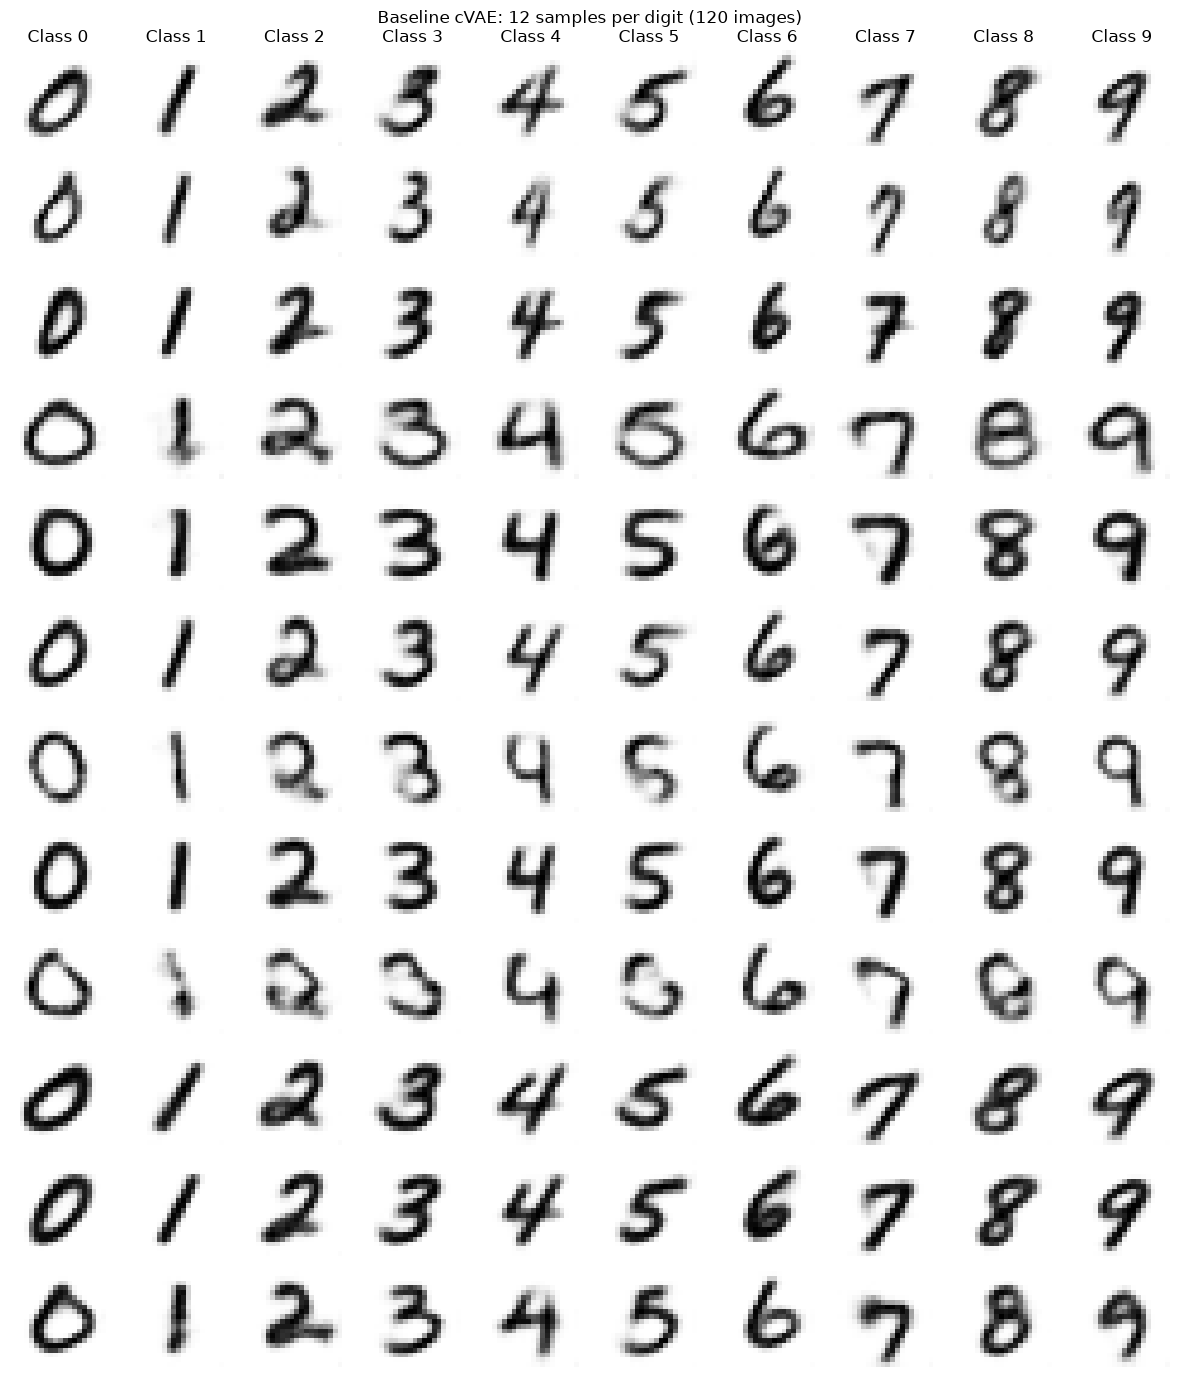

In [9]:
grid_base = sample_grid(cvae_base, z_base,
                        'Baseline cVAE: 12 samples per digit (120 images)',
                        'main_grid_baseline.png')

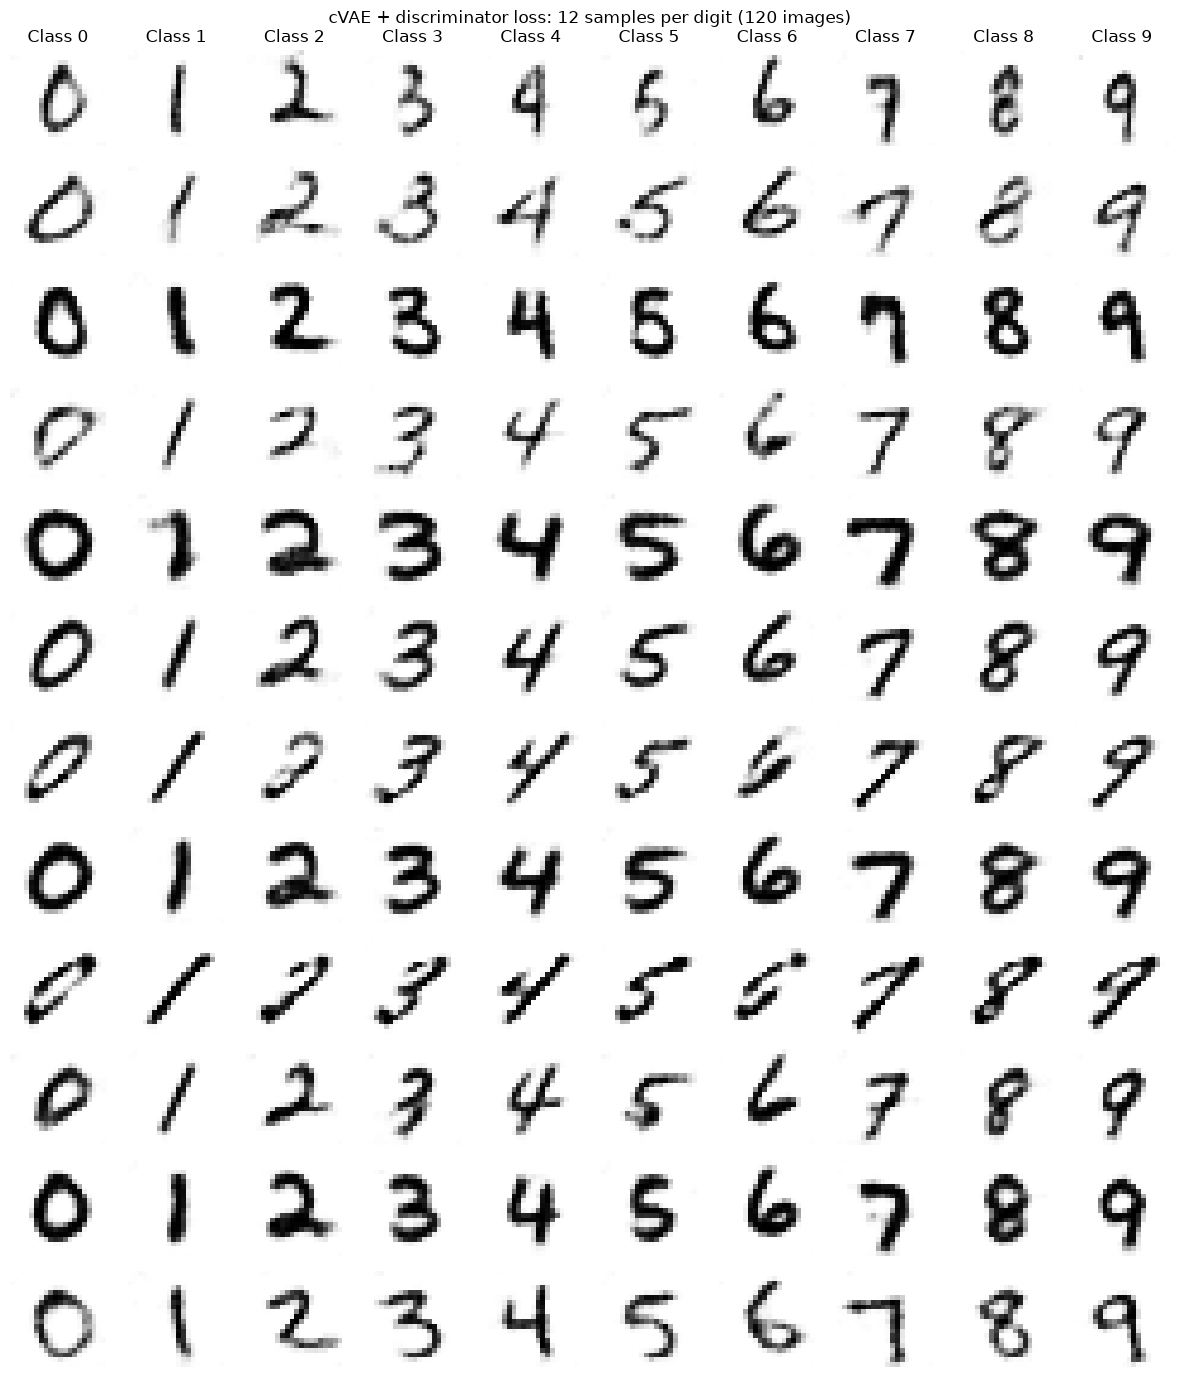

In [10]:
grid_disc = sample_grid(cvae_disc, z_disc,
                        'cVAE + discriminator loss: 12 samples per digit (120 images)',
                        'main_grid_disc.png')

In [11]:
def laplacian_variance(images):
    """
    Sharpness metric. Convolve with a Laplacian kernel (a second-derivative
    filter) and take the variance of the response per image. Blurry images
    carry little high-frequency content, so the response is flat and the
    variance is small; crisp edges give a large response.
    images: (N, 1, 20, 20) float tensor in [0, 1] -> (N,) scores
    """
    kernel = torch.tensor([[0.,  1., 0.],
                           [1., -4., 1.],
                           [0.,  1., 0.]]).view(1, 1, 3, 3)
    resp = F.conv2d(images, kernel, padding=1)
    return resp.view(images.shape[0], -1).var(dim=1)


# flatten (10, 12, 1, 20, 20) -> (120, 1, 20, 20), ordered digit 0 x12, digit 1 x12, ...
imgs_base = grid_base.reshape(-1, 1, 20, 20).float()
imgs_disc = grid_disc.reshape(-1, 1, 20, 20).float()

lap_results = {}
for name, imgs in [('real data', real_imgs),
                   ('baseline cVAE', imgs_base),
                   ('cVAE + disc', imgs_disc)]:
    lv = laplacian_variance(imgs)
    lap_results[name] = (lv.mean().item(), lv.std().item())
    print(f'{name:16s} n={imgs.shape[0]:3d}  Laplacian variance: '
          f'{lv.mean():.4f} +/- {lv.std():.4f}')

real data        n=120  Laplacian variance: 0.3624 +/- 0.0515
baseline cVAE    n=120  Laplacian variance: 0.2672 +/- 0.0279
cVAE + disc      n=120  Laplacian variance: 0.3601 +/- 0.0575


In [12]:
# Standalone digit classifier used as a neutral judge: it is trained only on
# real images (in cVAE_DiscriminatorLoss.ipynb) and never sees generated data
# during training. Here we only load the saved weights.
class DigitClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(DigitClassifier, self).__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),                      # 64 * 3 * 3 = 576
        )
        self.head = nn.Sequential(
            nn.Linear(576, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


clf = DigitClassifier().to(device)
clf.load_state_dict(torch.load('digit_classifier.pth', map_location=device))
clf.eval()

# sanity check: the judge must be accurate on real data, or the numbers below
# would be meaningless
from torch.utils.data import TensorDataset, DataLoader
clf_test_loader = DataLoader(TensorDataset(d['test_images'], d['test_labels']),
                             batch_size=1000, shuffle=False, num_workers=0)
correct, total = 0, 0
with torch.no_grad():
    for x, y in clf_test_loader:
        x, y = x.to(device), y.to(device)
        correct += (clf(x).argmax(dim=1) == y).sum().item()
        total   += y.shape[0]
print(f'classifier accuracy on the full real test set: {correct/total:.4f}')

classifier accuracy on the full real test set: 0.9769


In [13]:
def evaluate_samples(model_name, imgs, num_samples=12, num_classes=10):
    """
    imgs: (120, 1, 20, 20), ordered digit 0 x12, digit 1 x12, ...
    accuracy   = does the classifier read each sample as the digit we conditioned on?
    confidence = mean softmax probability of the classifier's own top class
    """
    labels = torch.arange(num_classes).repeat_interleave(num_samples)
    with torch.no_grad():
        logits = clf(imgs.to(device))
        pred   = logits.argmax(dim=1).cpu()
        conf   = F.softmax(logits, dim=1).max(dim=1).values.cpu()

    acc = (pred == labels).float().mean().item()
    per_digit = [(pred[i*num_samples:(i+1)*num_samples] == i).float().mean().item()
                 for i in range(num_classes)]
    print(f'{model_name:16s} accuracy {acc:.4f}   mean confidence {conf.mean():.4f}')
    print('   per-digit accuracy: ' +
          '  '.join(f'{i}:{a:.2f}' for i, a in enumerate(per_digit)))
    return acc, conf.mean().item(), per_digit


with torch.no_grad():
    real_pred = clf(real_imgs.to(device)).argmax(dim=1).cpu()
acc_real = (real_pred == real_labels).float().mean().item()
print(f'{"real data":16s} accuracy {acc_real:.4f}   (upper reference)')

acc_b, conf_b, pd_b = evaluate_samples('baseline cVAE', imgs_base)
acc_d, conf_d, pd_d = evaluate_samples('cVAE + disc',   imgs_disc)

# summary table as reported
print('\n' + '=' * 72)
print(f'{"model":18s}{"LapVar":>18s}{"clf accuracy":>16s}{"confidence":>14s}')
print('-' * 72)
m, s = lap_results['real data']
print(f'{"real data":18s}{m:>10.4f} +/-{s:5.4f}{acc_real:>16.4f}{"-":>14s}')
m, s = lap_results['baseline cVAE']
print(f'{"baseline cVAE":18s}{m:>10.4f} +/-{s:5.4f}{acc_b:>16.4f}{conf_b:>14.4f}')
m, s = lap_results['cVAE + disc']
print(f'{"cVAE + disc":18s}{m:>10.4f} +/-{s:5.4f}{acc_d:>16.4f}{conf_d:>14.4f}')
print('=' * 72)
print('\nNote: n = 120 generated images per model. The accuracy gap corresponds to')
print('3 images, which is too small to be conclusive; the sharpness gap is large.')

real data        accuracy 0.9917   (upper reference)
baseline cVAE    accuracy 0.9917   mean confidence 0.9732
   per-digit accuracy: 0:1.00  1:1.00  2:1.00  3:1.00  4:1.00  5:1.00  6:1.00  7:1.00  8:0.92  9:1.00
cVAE + disc      accuracy 0.9667   mean confidence 0.9629
   per-digit accuracy: 0:0.92  1:1.00  2:0.92  3:1.00  4:1.00  5:1.00  6:0.83  7:1.00  8:1.00  9:1.00

model                         LapVar    clf accuracy    confidence
------------------------------------------------------------------------
real data             0.3624 +/-0.0515          0.9917             -
baseline cVAE         0.2672 +/-0.0279          0.9917        0.9732
cVAE + disc           0.3601 +/-0.0575          0.9667        0.9629

Note: n = 120 generated images per model. The accuracy gap corresponds to
3 images, which is too small to be conclusive; the sharpness gap is large.
